## Data In high dimensions / The curse of dimensionality
Random vectors in high dimension behave very differently from low dimensional vectors. 

Our intuition fails us.

For a better understanding, rely on the law of large numbers and central limit theorem.


In [11]:
from lib.Kmeans_generate_and_analyze import *
from numpy.random import randint


In [12]:
def gen_data(k=2,n=1000,d=2,radius=5):
    df,centers=create_data(k,n,d,radius=radius)
    #print(centers)
    M=np.array(df.iloc[:,:-1])
    return M

def my_hist(L,_title,one_side=True,_xlim=[-10,10]):
    hist(L,bins=50);
    title(_title)
    if one_side:
        xlim([0,max(L)*1.3])
    else:
        xlim(_xlim)
    
    grid()
    return None

## Length of a vector drawn from a gaussian
We start with the simplest high dimensional distribution: A gaussian with mean zero and std 1 in all directions.

* $\vec{x}$ is a random vector drawn from a spherical gaussian centered at zero.
* Alternatively: $x_1,\ldots,x_d$ are drawn **independently** from the standard normal $N(0,1)$
* We plot the distribution of the **square** of the length of $\vec{x}$ which is 
$$\|\vec{x}\|^2 = \sum_{i=1}^d x_i^2$$
* for dimensions $d=2,10,200,2000$

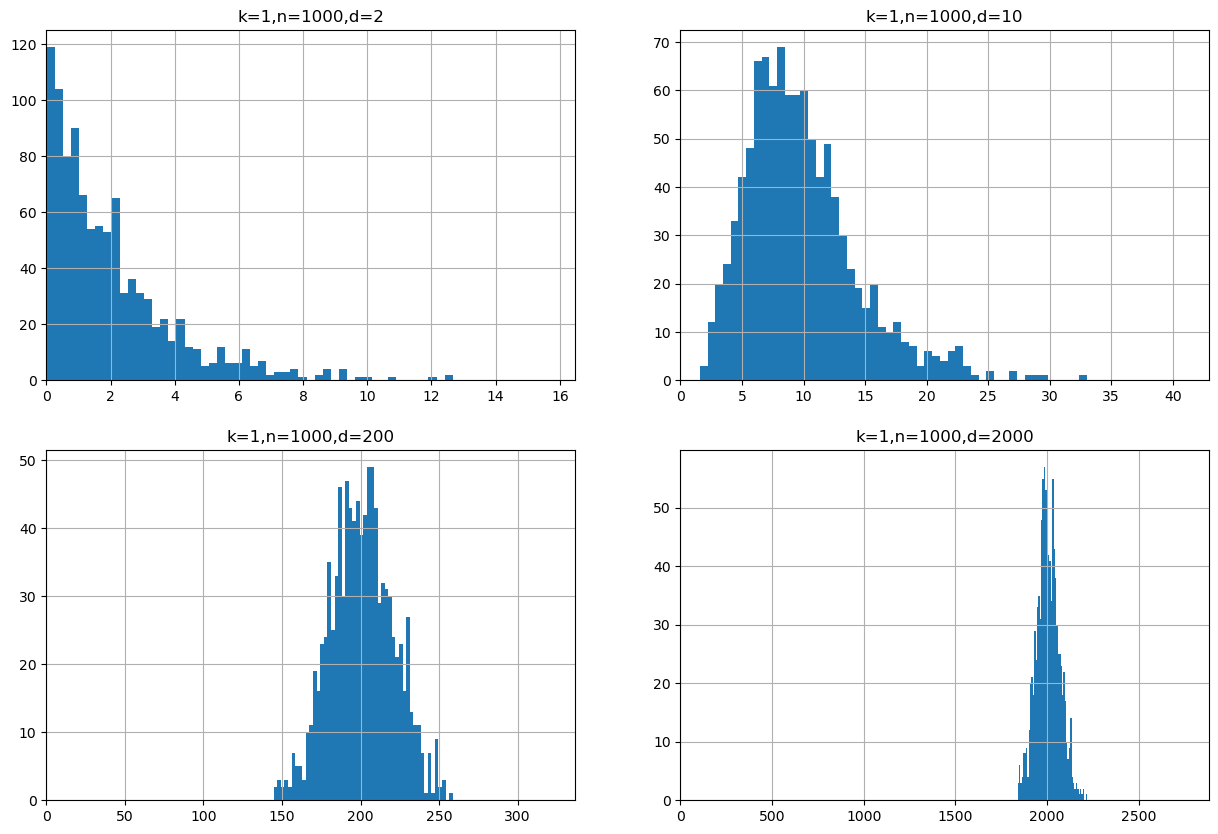

In [13]:
_d=[2,10,200,2000]
figure(figsize=[15,10])
for i in range(len(_d)):
    subplot(2,2,i+1);
    k=1;n=1000;d=_d[i]
    M=gen_data(k,n,d,radius=0.0)
    L=np.sum(M**2,axis=1)
    my_hist(L,_title='k=%d,n=%d,d=%d'%(k,n,d))

* For $d=2$: $\|\vec{x}\|$ is concentrated around 0
* For $d \to \infty$ the diatribution of $\|\vec{x}\|^2$ becomes concentrated around $d$

### What is the explanation?

* The length-squared of $\vec{x}$ is $\sum_{i=1}^d x_i^2$
* The cordinates $x_1,x_2,\ldots x_d$ are independent
* Define $y_i=x_i^2$, $y_i$ are also indpendent.
* $\mu = E[y]=1$, $\sigma^2=Var[y]$ 

* $E[y_1+\ldots+y_d] = d \mu = d$
* $Var[y_1+\ldots+y_d] = d \sigma^2$
* $std[y_1+\ldots+y_d] = \sqrt{d} \sigma$

* $E[x_1^2+\ldots+y_1^2] = d$
* $std[x_1^2+\ldots+x_d^2]$ is $O(\sqrt{d})$
* $\|\vec{x}\|^2$ is concentrated in $d \pm \sigma \sqrt{d}$
* $\|\vec{x}\|$ is concentrated in $\sqrt{d} \pm constant$

* **General Pattern** the random variable of interest is the sum of $d$ indpendent random variables.

## Distance between two points drawn randomly from a mixture

We have two spherical gaussians with std 1, centered at $x=-5$ and $x=5$.

As the dimension increases, the distance between two points becomes dominated by the $d-1$ dimensions where there is no separation.

At very high dimension, the distance between two points in the same cluster is indistinguishable from the distance between two points in different clusters.

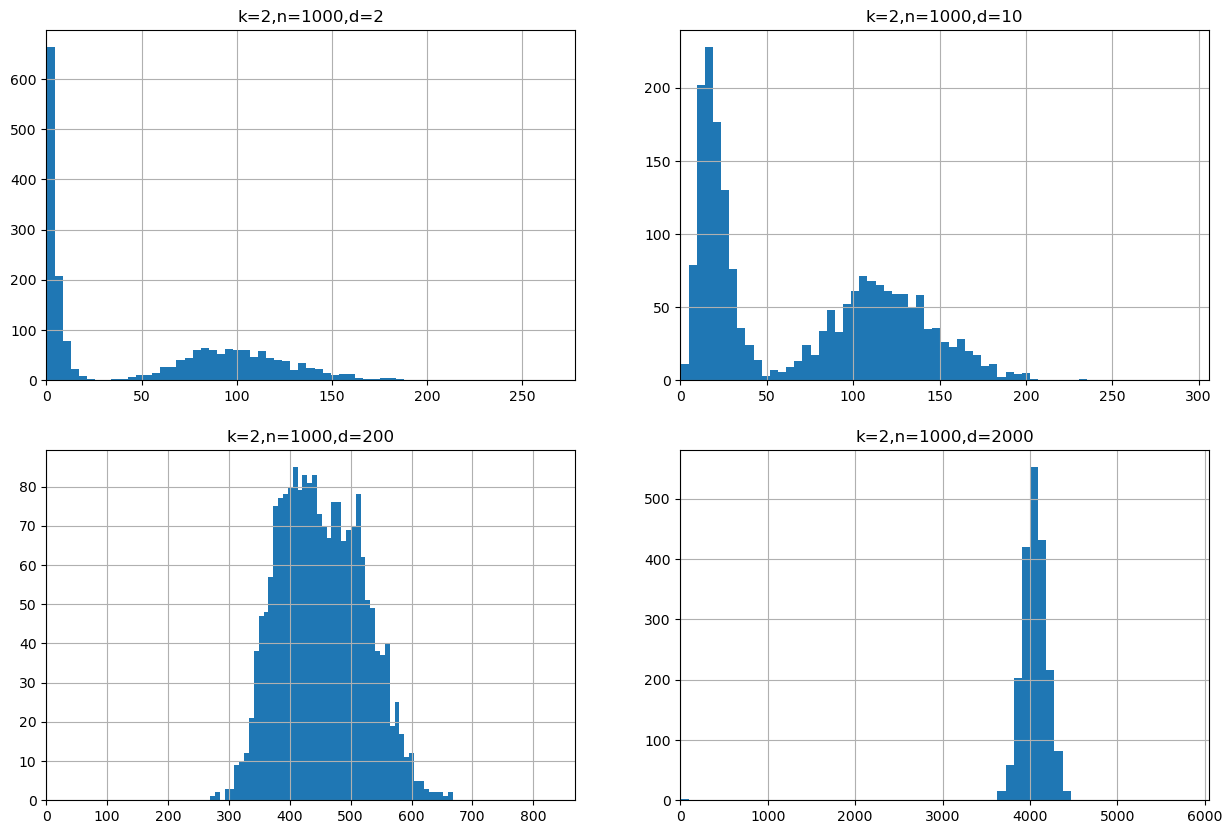

In [21]:
figure(figsize=[15,10])
for i in range(len(_d)):
    subplot(2,2,i+1);
    k=2;n=1000;d=_d[i]
    M=gen_data(k,n,d)
    l=M.shape[0]
    I=randint(l,size=[l,2])

    X0=M[I[:,0],:]
    X1=M[I[:,1],:]
    L=np.sum((X0-X1)**2,axis=1)

    my_hist(L,_title='k=%d,n=%d,d=%d'%(k,n,d))

When we have just two dimensions there is a clear distinction between small distances - where the two points are in the same cluster, and large distances, where they belong to different clusters.

### Why?
The distance between two points has two contributions:
* Distance between clusters from which the points came: 0 or 5
* The distance between two random points -  a sum of independent random variables.

In high dimension the second contribution dominates the first.

### K-nearest-neighbors fails in high dimensions
* Suppose one gaussian is labeled +1 and the other -1.
* Can we use the k-NN classifier to identify the cluster from which the data point came?
* In low dimension - yes.
* In high dimensions - no. 
* Given two vectors, the distance between them is about $\sqrt{d}$ regardless of whether they are from the same or opposite clusters.

## Dot Products

When we take the dot product between two random vectors we expect that, because of the two clusters, the result would be concentrater around $5\times -5 = -25$ or $5\times 5=+25$.

That is true for dimension 2 and for dimension 20. But when we reach dimenson 200, the peaks have a large overlap, and when we reach 2000 they are indistinguishable.

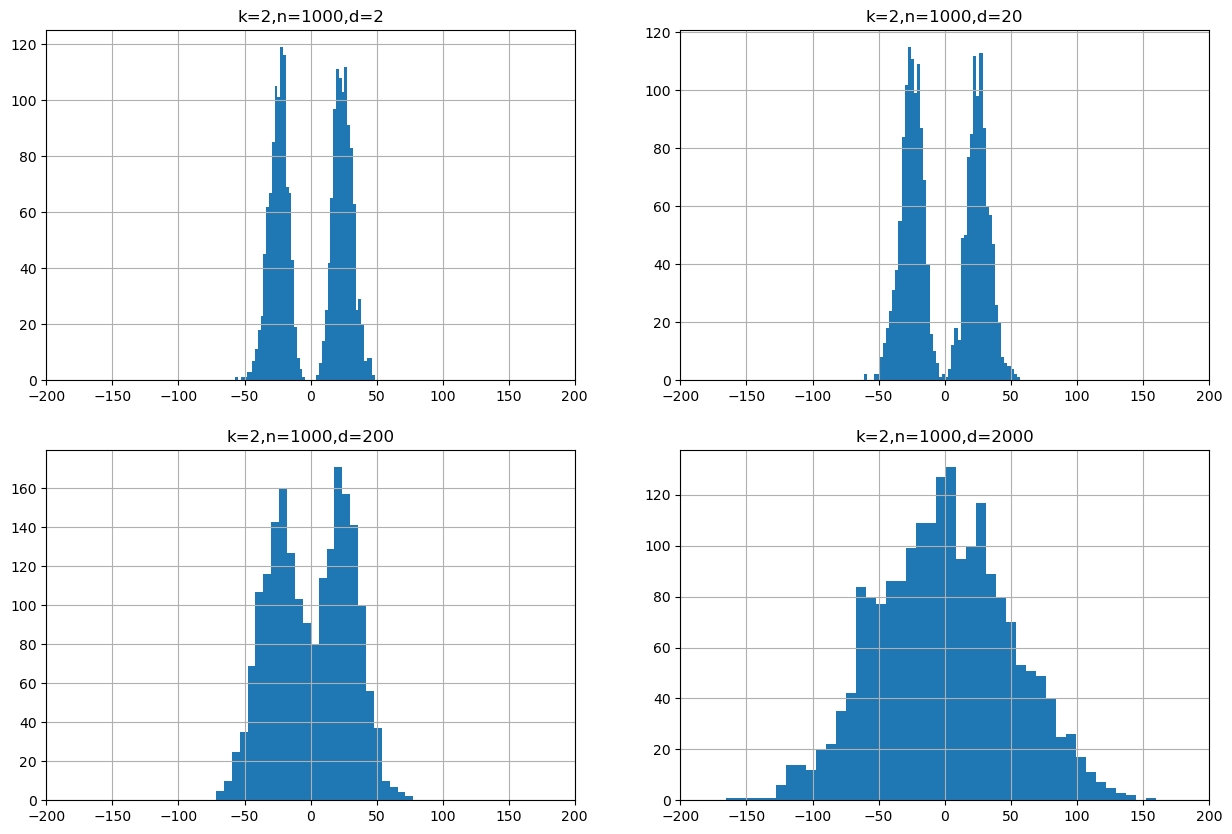

In [17]:
figure(figsize=[15,10])
for i in range(len(_d)):
    subplot(2,2,i+1);
    k=2;n=1000;d=_d[i]
    M=gen_data(k,n,d,radius=5)
    l=M.shape[0]
    I=randint(l,size=[l,2])

    X0=M[I[:,0],:]
    X1=M[I[:,1],:]
    L=np.sum(X0*X1,axis=1)

    my_hist(L,_title='k=%d,n=%d,d=%d'%(k,n,d),one_side=False,_xlim=[-200,200])


### General pattern
$$\vec{x}\cdot \vec{y} = \sum_{i=1}^d x_i y_i$$

### Summary

* The 2d and 3D intuitions break down at high dimensions. The lengths of vectors, the distance between vectors and the dot products between vectors all become highly concentrated and therefor not informative.
* **The curse of dimensionality** : Most statistical methods break down at high dimensions.
* A way out: some high dimensional data has low **intrinsic dimension**